**Step 2: Import libraries**

In [1]:
import os
import re
import cv2
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import kagglehub

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["image.cmap"] = "gray"

**Step 3: Mount Google Drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Step 4: Download dataset from Kaggle**

In [3]:
DOWNLOAD_DIR = Path(
    kagglehub.dataset_download("nizier193/leaf-segmentation-dataset-mk7")
)

print("Downloaded to:", DOWNLOAD_DIR)

DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/simple_segmentation_training")
DRIVE_PROJECT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_DIR = DRIVE_PROJECT_DIR / "dataset"

if not DATASET_DIR.exists():
    shutil.copytree(DOWNLOAD_DIR, DATASET_DIR)
    print("Copied dataset to Drive:", DATASET_DIR)
else:
    print("Dataset already exists in Drive:", DATASET_DIR)

100%|██████████| 22.7M/22.7M [00:00<00:00, 75.2MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/nizier193/leaf-segmentation-dataset-mk7/versions/1
Copied dataset to Drive: /content/drive/MyDrive/simple_segmentation_training/dataset


**Step 5: Inspect the dataset folders**

In [4]:
for root, dirs, files in os.walk(DATASET_DIR):
    level = root.replace(str(DATASET_DIR), "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{Path(root).name}/")
    for f in files[:3]:
        print(" " * 2 * (level + 1) + f)
    if level >= 2:
        continue

dataset/
  aug/
    images/
      image-265-1.jpg
      image-91-0.jpg
      image-189-1.jpg
    masks/
      mask-127-0.jpg
      mask-209-1.jpg
      mask-58-1.jpg


**Step 6: Find image and mask folders**

In [5]:
image_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

all_dirs = [p for p in DATASET_DIR.rglob("*") if p.is_dir()]

def count_images(folder):
    return len([p for p in folder.glob("*") if p.suffix.lower() in image_exts])

image_candidates = []
mask_candidates = []

for d in all_dirs:
    name = d.name.lower()
    n_files = count_images(d)
    if n_files == 0:
        continue

    if any(k in name for k in ["image", "images", "img", "rgb"]):
        image_candidates.append((d, n_files))
    if any(k in name for k in ["mask", "masks", "label", "labels", "annotation", "annotations"]):
        mask_candidates.append((d, n_files))

print("Image candidates:")
for d, n in image_candidates[:10]:
    print("-", d, "|", n)

print("\nMask candidates:")
for d, n in mask_candidates[:10]:
    print("-", d, "|", n)

Image candidates:
- /content/drive/MyDrive/simple_segmentation_training/dataset/aug/images | 552

Mask candidates:
- /content/drive/MyDrive/simple_segmentation_training/dataset/aug/masks | 552


**Step 7: Select the folders**

In [6]:
IMAGE_DIR = sorted(image_candidates, key=lambda x: x[1], reverse=True)[0][0]
MASK_DIR = sorted(mask_candidates, key=lambda x: x[1], reverse=True)[0][0]

print("IMAGE_DIR:", IMAGE_DIR)
print("MASK_DIR :", MASK_DIR)

IMAGE_DIR: /content/drive/MyDrive/simple_segmentation_training/dataset/aug/images
MASK_DIR : /content/drive/MyDrive/simple_segmentation_training/dataset/aug/masks


**Step 8: Helper functions**

In [7]:
def read_image(path, size=(256, 256)):
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    return img

def read_mask(path, size=(256, 256)):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, size)
    _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    return mask

def show_many(images, titles, cols=3, size=(15, 8)):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=size)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(img)
        plt.title(titles[i])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def overlay_mask(image, mask, color=(255, 0, 0), alpha=0.35):
    out = image.copy()
    color_layer = np.zeros_like(image)
    color_layer[:, :] = color
    mask_bool = mask > 0
    out[mask_bool] = cv2.addWeighted(image[mask_bool], 1-alpha, color_layer[mask_bool], alpha, 0)
    return out

**Step 9: Build image-mask pairs**

In [8]:
def list_image_files(folder):
    return sorted([p for p in folder.rglob("*") if p.suffix.lower() in image_exts])

def extract_id(name):
    name = Path(name).stem.lower()
    m = re.search(r"(\d+-\d+)$", name)
    if m:
        return m.group(1)

    nums = re.findall(r"\d+", name)
    if len(nums) >= 2:
        return f"{nums[-2]}-{nums[-1]}"
    elif len(nums) == 1:
        return nums[0]
    return name

def build_pairs(image_dir, mask_dir):
    image_files = list_image_files(image_dir)
    mask_files = list_image_files(mask_dir)

    mask_map = {}
    for m in mask_files:
        mask_map[extract_id(m.name)] = m

    pairs = []
    for img_path in image_files:
        key = extract_id(img_path.name)
        if key in mask_map:
            pairs.append((img_path, mask_map[key]))

    return pairs

pairs = build_pairs(IMAGE_DIR, MASK_DIR)

print("Images found:", len(list_image_files(IMAGE_DIR)))
print("Masks found :", len(list_image_files(MASK_DIR)))
print("Pairs found :", len(pairs))

Images found: 552
Masks found : 552
Pairs found : 552


**Step 10: Preview one image and its mask**

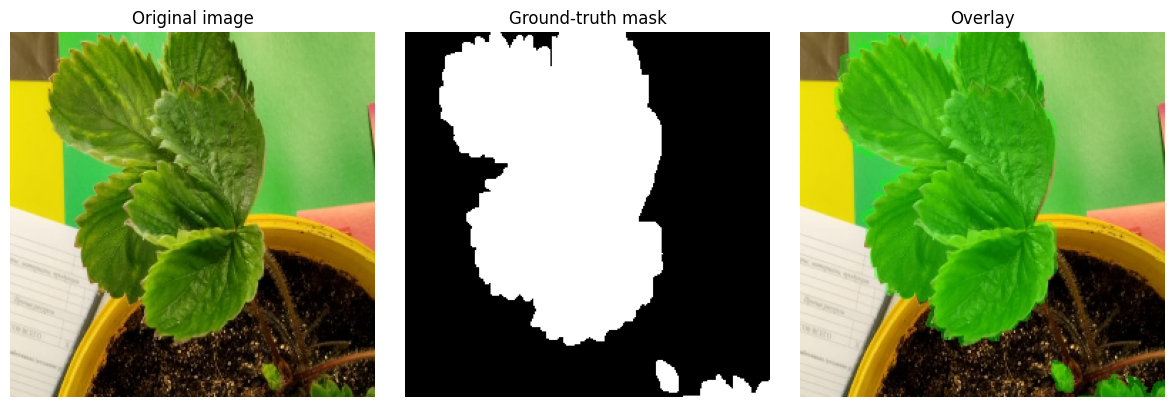

Image: image-0-0.jpg
Mask : mask-0-0.jpg


In [9]:
if len(pairs) == 0:
    raise ValueError("No image-mask pairs found. Check IMAGE_DIR and MASK_DIR.")

img_path, mask_path = pairs[0]

img = read_image(img_path)
gt = read_mask(mask_path)
over = overlay_mask(img, gt, color=(0, 255, 0))

show_many(
    [img, gt, over],
    ["Original image", "Ground-truth mask", "Overlay"],
    cols=3,
    size=(12, 4)
)

print("Image:", img_path.name)
print("Mask :", mask_path.name)

**Simple segmentation method**

In [10]:
def largest_component(binary):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if num_labels <= 1:
        return binary

    areas = stats[1:, cv2.CC_STAT_AREA]
    largest_idx = 1 + np.argmax(areas)

    out = np.zeros_like(binary)
    out[labels == largest_idx] = 255
    return out

def segment_simple(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    _, mask = cv2.threshold(
        blur, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    mask = largest_component(mask)
    return gray, blur, mask

**Step 11: Apply simple segmentation to one image**

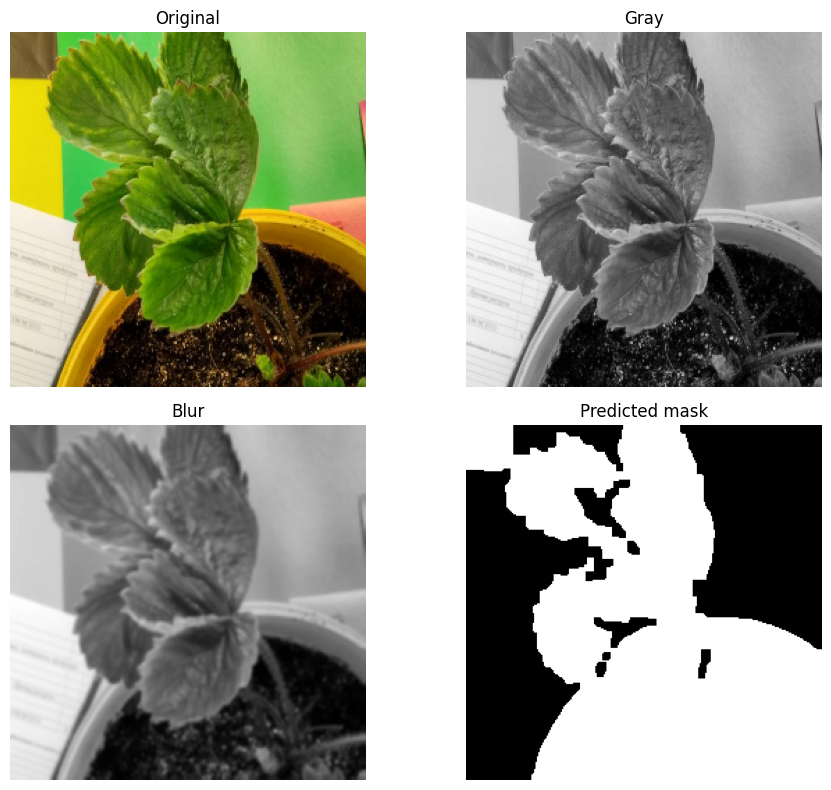

In [11]:
gray, blur, pred = segment_simple(img)

show_many(
    [img, gray, blur, pred],
    ["Original", "Gray", "Blur", "Predicted mask"],
    cols=2,
    size=(10, 8)
)

**Step 12: Compare true mask and predicted mask**

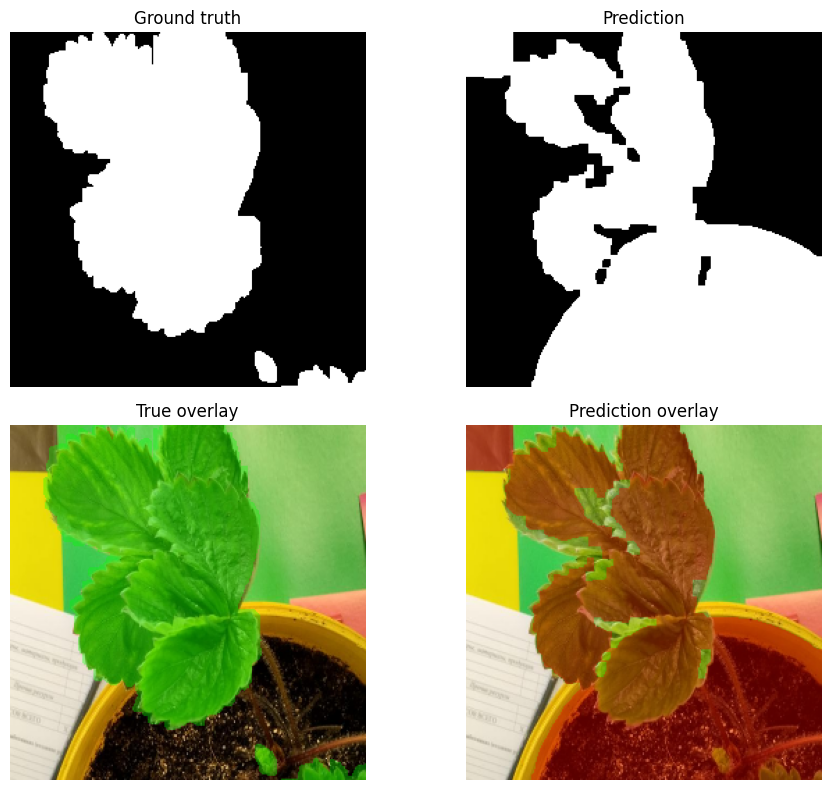

In [12]:
show_many(
    [gt, pred, overlay_mask(img, gt, color=(0, 255, 0)), overlay_mask(img, pred, color=(255, 0, 0))],
    ["Ground truth", "Prediction", "True overlay", "Prediction overlay"],
    cols=2,
    size=(10, 8)
)

**Metrics**

In [13]:
def to_binary(mask):
    return (mask > 0).astype(np.uint8)

def segmentation_metrics(y_true, y_pred):
    y_true = to_binary(y_true).flatten()
    y_pred = to_binary(y_pred).flatten()

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)
    dice = 2 * tp / (2 * tp + fp + fn + 1e-8)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "iou": iou,
        "dice": dice
    }

**Step 13: Measure metrics for one image**

In [14]:
metrics = segmentation_metrics(gt, pred)

for k, v in metrics.items():
    print(f"{k:10s}: {v:.4f}")

accuracy  : 0.7066
precision : 0.5993
recall    : 0.8383
f1_score  : 0.6990
iou       : 0.5372
dice      : 0.6990


**Step 14: Evaluate several images**

In [15]:
results = []

for img_path, mask_path in pairs[:50]:
    img = read_image(img_path)
    gt = read_mask(mask_path)
    _, _, pred = segment_simple(img)

    m = segmentation_metrics(gt, pred)
    row = {"image": img_path.name}
    row.update(m)
    results.append(row)

df = pd.DataFrame(results)
df.head()

,image,accuracy,precision,recall,f1_score,iou,dice
0,image-0-0.jpg,0.706558,0.599345,0.838277,0.698956,0.537227,0.698956
1,image-0-1.jpg,0.605835,0.732726,0.718291,0.725437,0.569165,0.725437
2,image-1-0.jpg,0.688293,0.470018,0.950381,0.628973,0.458761,0.628973
3,image-1-1.jpg,0.668976,0.418026,0.836486,0.557464,0.386447,0.557464
4,image-10-0.jpg,0.705688,0.713589,0.640945,0.675319,0.509797,0.675319


**Step 15: Average results**

In [16]:
summary = df.mean(numeric_only=True)
summary

,0
accuracy,0.678429
precision,0.694515
recall,0.659454
f1_score,0.622773
iou,0.492889
dice,0.622773


**Step 16: Save results to Google Drive**

In [17]:
RESULTS_DIR = DRIVE_PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(RESULTS_DIR / "simple_segmentation_results.csv", index=False)

print("Saved to:", RESULTS_DIR / "simple_segmentation_results.csv")

Saved to: /content/drive/MyDrive/simple_segmentation_training/results/simple_segmentation_results.csv


1. **Why do we convert the image to grayscale?**
Colored images contain a lot of complex data (Red, Green, and Blue channels). By converting the image to black-and-white (grayscale), we make it much faster and easier for the computer to focus purely on shapes, contrast, and light/dark areas without getting distracted by colors.

2. **Why do we apply Gaussian blur?**
To smooth out tiny, irrelevant details and "noise" in the picture. Applying a blur helps the computer ignore rough textures or tiny dots so it can more easily find the main object's overall shape and smooth edges.

3. **What does Otsu thresholding do?**
Thresholding is the process of turning pixels into either pure black (the background) or pure white (the object). Otsu is a smart mathematical method that automatically figures out the absolute best dividing line to separate the light pixels from the dark pixels, without you having to guess the exact number yourself.

4. **Why do we use opening and closing?**
These are cleanup steps used to fix mistakes in the mask:

Opening: Acts like an eraser that wipes away tiny white dots (noise) that accidentally got selected in the dark background.

Closing: Acts like a filler to patch up tiny black holes or gaps that accidentally appeared inside the white main object, ensuring it remains one solid, unbroken shape.

5. **Why do we keep the largest component?**
Usually, the main object we are trying to find is the biggest thing in the picture. Keeping only the largest solid shape is a very quick and easy way to automatically throw away any random, unwanted small shapes that survived the cleanup process.

6. **Which metric is more useful: IoU or Dice?**
Both measure how accurate your result is, but they look at it slightly differently:

IoU (Intersection over Union) is stricter. It heavily penalizes mistakes if the edges of your predicted shape don't perfectly align with the true shape's edges.

Dice is slightly more forgiving and focuses heavily on how well the overall center masses of the areas match up.

**Task 1**

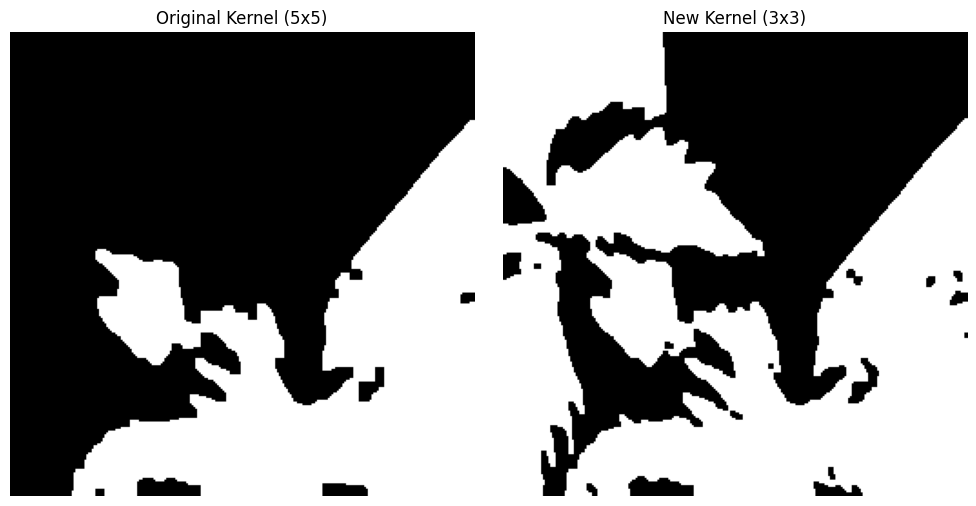

In [26]:
def segment_task1(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    mask = largest_component(mask)
    return mask

pred_task1 = segment_task1(img)

show_many(
    [pred, pred_task1],
    ["Original Kernel (5x5)", "New Kernel (3x3)"],
    cols=2, size=(10, 5)
)

**Task 2**

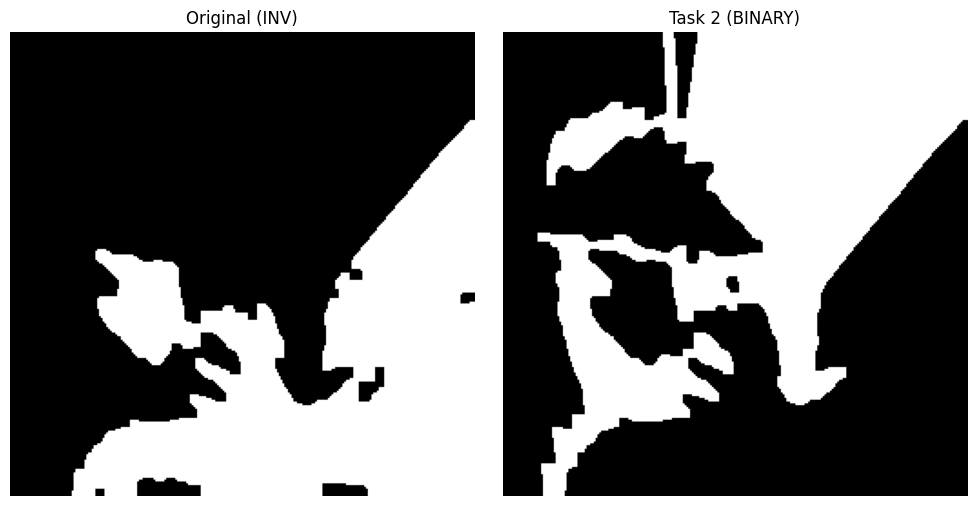

In [25]:
def segment_task2(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    mask = largest_component(mask)
    return mask

pred_task2 = segment_task2(img)

show_many(
    [pred, pred_task2],
    ["Original (INV)", "Task 2 (BINARY)"],
    cols=2, size=(10, 5)
)

**Task 3**

In [24]:
task3_results = []
for img_path, mask_path in pairs[50:60]:
    img_test = read_image(img_path)
    gt_test = read_mask(mask_path)
    _, _, pred_test = segment_simple(img_test)

    m = segmentation_metrics(gt_test, pred_test)
    row = {"image": img_path.name}
    row.update(m)
    task3_results.append(row)

df_task3 = pd.DataFrame(task3_results)
print("Yangi 10 ta rasmning o'rtacha natijalari:")
display(df_task3.mean(numeric_only=True))

Yangi 10 ta rasmning o'rtacha natijalari:


,0
accuracy,0.749554
precision,0.631671
recall,0.533295
f1_score,0.540819
iou,0.432013
dice,0.540819


**Task 4**


--- TOP 3 SUCCESS CASES (Eng yaxshi natijalar) ---


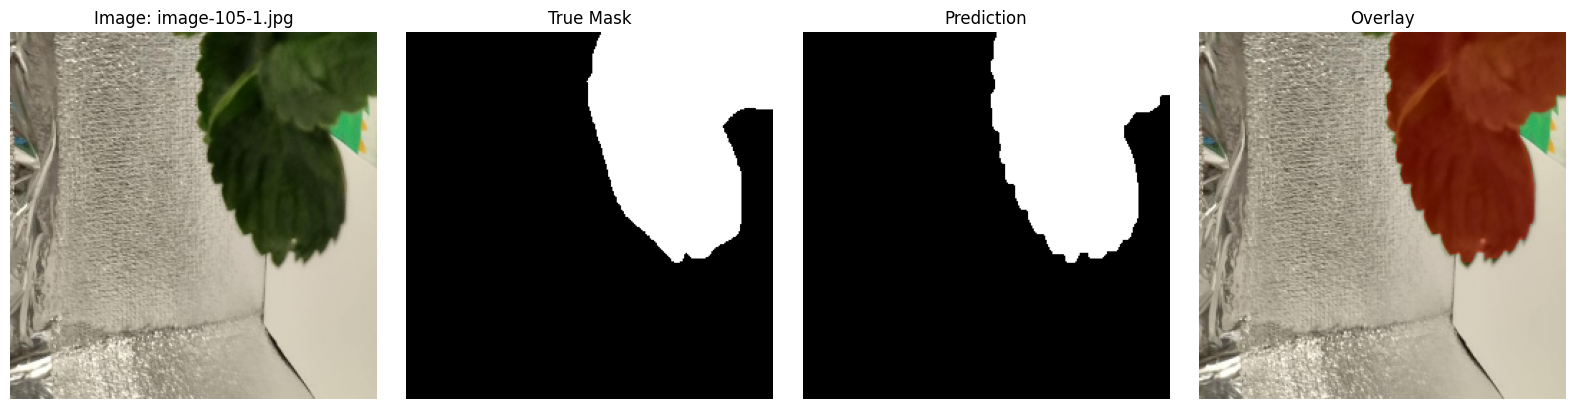

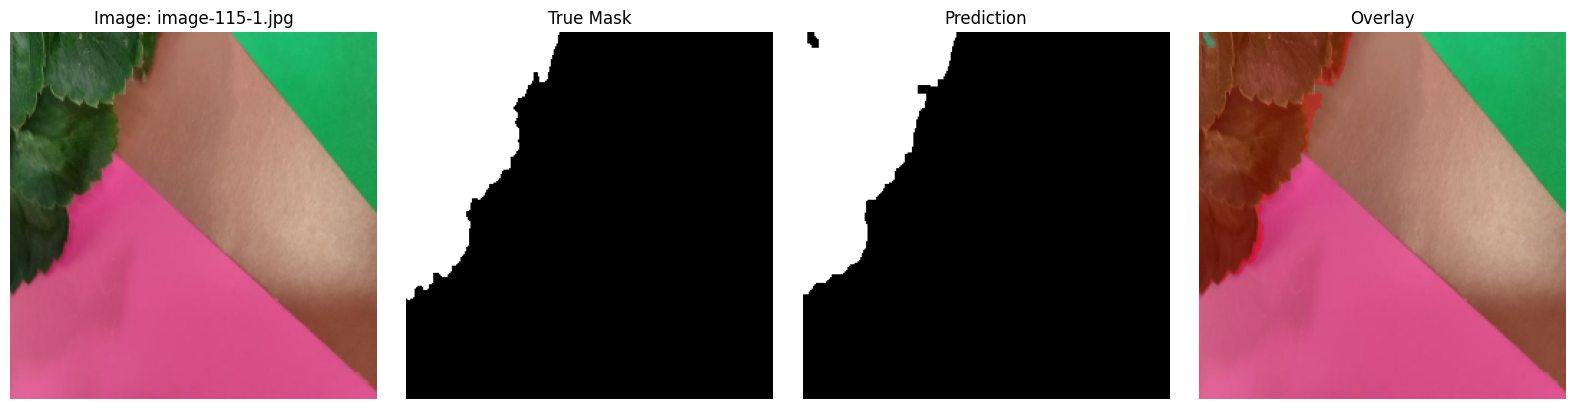

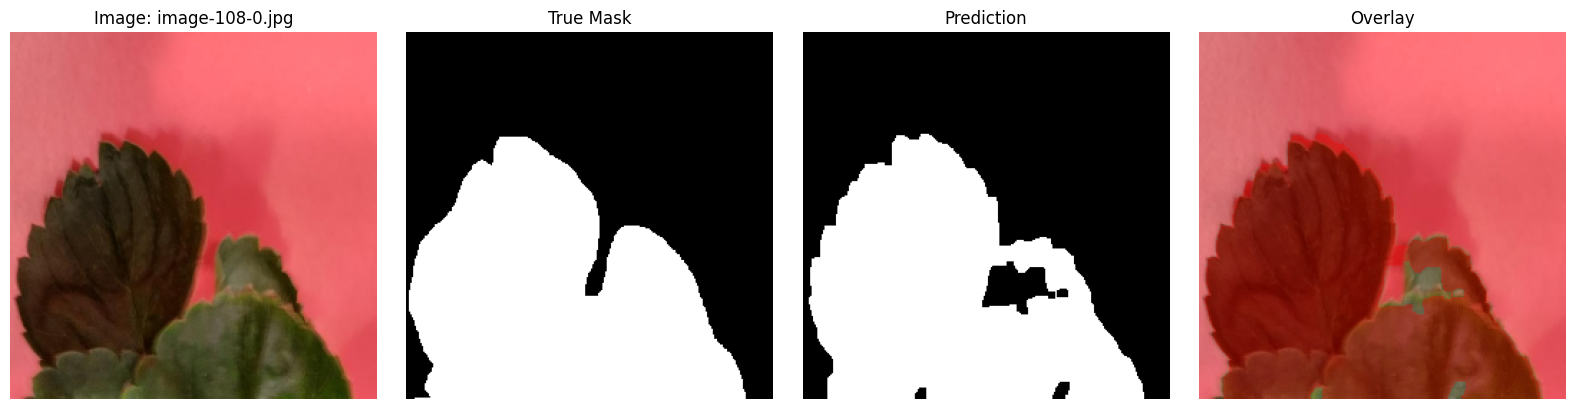


--- TOP 3 FAILURE CASES (Eng yomon natijalar) ---


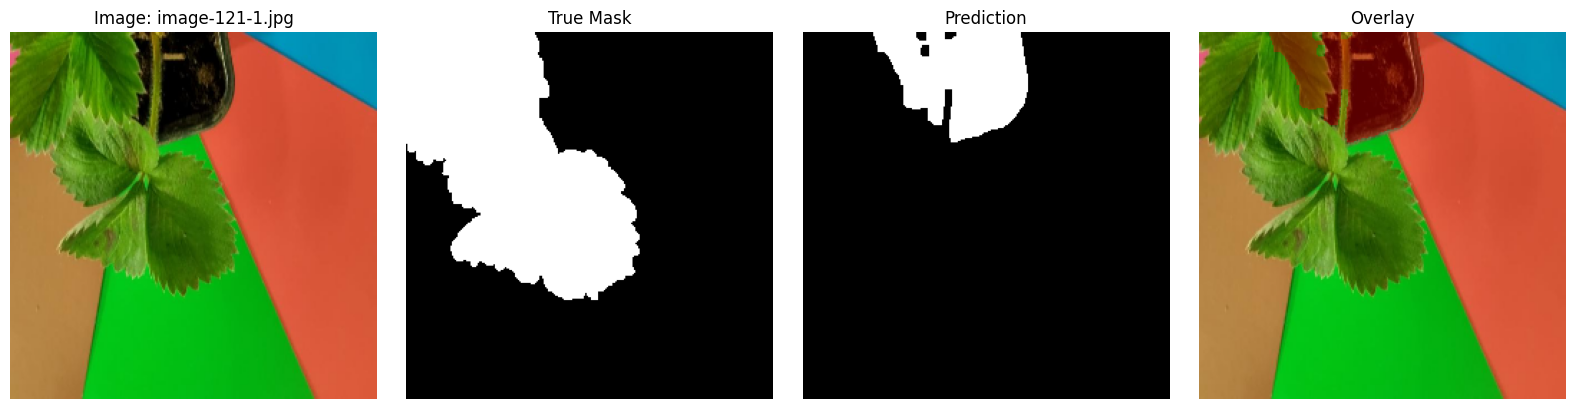

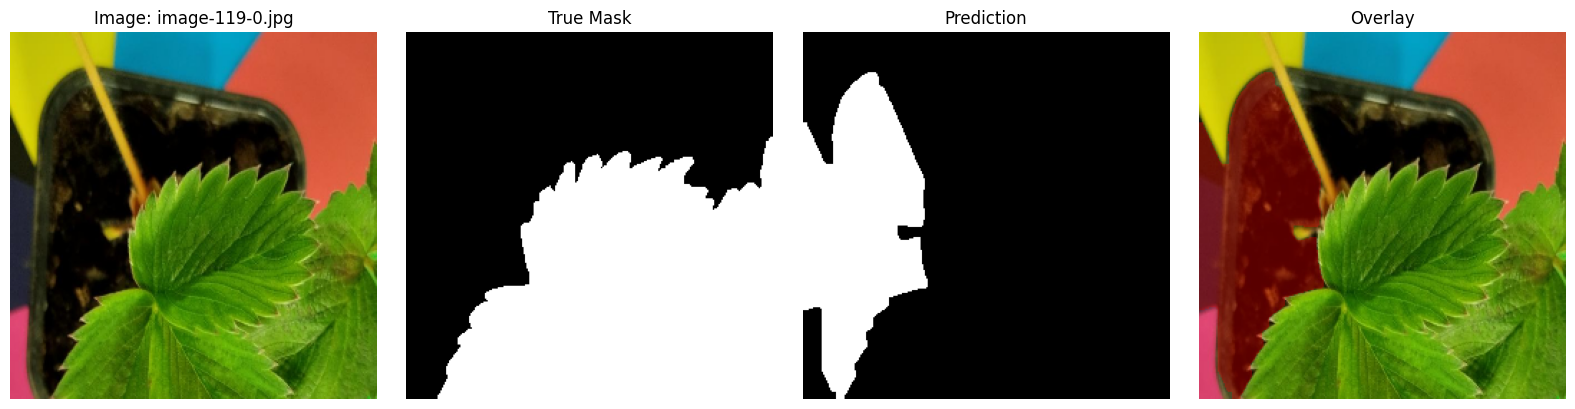

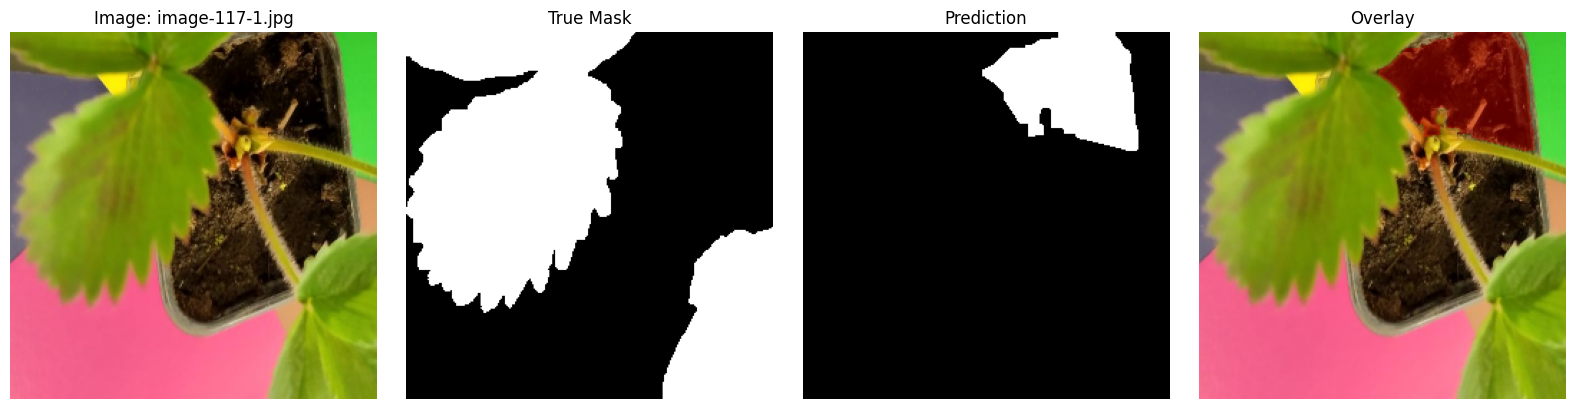

In [23]:
df_sorted = df.sort_values(by="iou", ascending=False)

success_cases = df_sorted.head(3)["image"].tolist()
failure_cases = df_sorted.tail(3)["image"].tolist()

def show_cases(case_list, title):
    print(f"\n--- {title} ---")
    for img_name in case_list:
        img_path = next(p[0] for p in pairs if p[0].name == img_name)
        mask_path = next(p[1] for p in pairs if p[0].name == img_name)

        i = read_image(img_path)
        gt = read_mask(mask_path)
        _, _, p = segment_simple(i)

        show_many(
            [i, gt, p, overlay_mask(i, p, color=(255,0,0))],
            [f"Image: {img_name}", "True Mask", "Prediction", "Overlay"],
            cols=4, size=(16, 4)
        )

show_cases(success_cases, "TOP 3 SUCCESS CASES (Eng yaxshi natijalar)")
show_cases(failure_cases, "TOP 3 FAILURE CASES (Eng yomon natijalar)")

**Task 5**

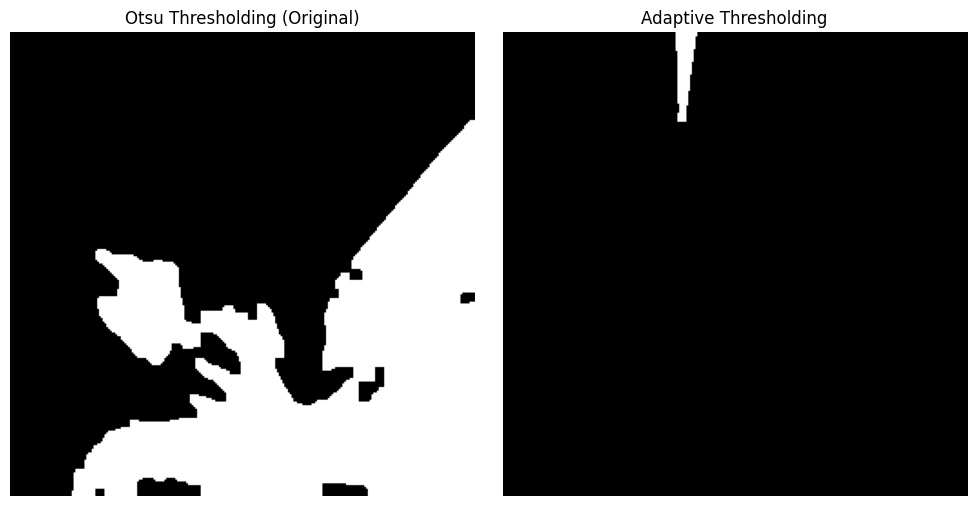

In [22]:
def segment_task5(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    mask = cv2.adaptiveThreshold(
        blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11, 2
    )

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    mask = largest_component(mask)
    return mask

pred_adaptive = segment_task5(img)

show_many(
    [pred, pred_adaptive],
    ["Otsu Thresholding (Original)", "Adaptive Thresholding"],
    cols=2, size=(10, 5)
)